# AAV9 log enrichment — Production1 vs Production2

`fit4functionaav9.csv` (this folder) holds two independent production replicates for the
same library, `Production1`/`Production2` (plus their average `Production`). These are raw
fold-enrichment ratios, not yet log-transformed. This notebook converts each to a **log2
enrichment** (`log2(Production1)`, `log2(Production2)`) and plots the two histograms, to look
at reproducibility between the two production experiments.

`Production1`/`Production2` contain some `0` and `inf` entries (variants never detected at one
of the two NGS checkpoints) plus a handful of `NaN` rows -- none of these have a defined log2,
so they're dropped before plotting and the dropped fraction is reported explicitly rather than
silently discarded.

## 0. Load data

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("fit4functionaav9.csv")
print(f"{len(df):,} rows, columns: {list(df.columns)}")
df[["Production1", "Production2", "Production"]].describe()

74,464 rows, columns: ['AA', 'CodonRep1', 'CodonRep2', 'Label', 'Production1', 'Production2', 'Production']


/home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/.venv/lib/python3.12/site-packages/pandas/core/nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/.venv/lib/python3.12/site-packages/pandas/core/nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/.venv/lib/python3.12/site-packages/pandas/core/nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,Production1,Production2,Production
count,7.445400e+04,7.445000e+04,7.444000e+04
mean,inf,inf,inf
std,NaN,NaN,NaN
min,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.249160e-03,2.181838e-03,3.042360e-03
50%,2.375576e-02,2.395781e-02,2.619087e-02
75%,7.441773e-01,7.464773e-01,9.115680e-01
max,inf,inf,inf


## 1. `log2` enrichment

Keep only rows where the replicate is finite and strictly positive (`log2` is undefined for
`0`/`inf`/`NaN`).

In [ ]:
def log2_enrichment(x: pd.Series) -> np.ndarray:
    name = x.name
    x = x.to_numpy(dtype=float)
    valid = np.isfinite(x) & (x > 0)
    dropped = len(x) - int(valid.sum())
    print(f"{name}: dropped {dropped:,}/{len(x):,} rows "
          f"({dropped / len(x):.1%}) with non-finite or non-positive value")
    return np.log2(x[valid])

log2_prod1 = log2_enrichment(df["Production1"])
log2_prod2 = log2_enrichment(df["Production2"])

Production1: dropped 12,692/74,464 rows (17.0%) with non-finite or non-positive value
Production2: dropped 12,823/74,464 rows (17.2%) with non-finite or non-positive value


## 2. Histograms

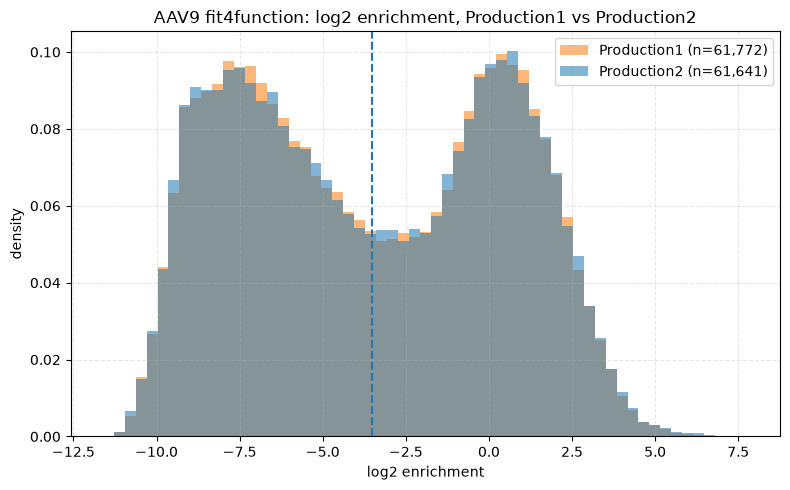

Production1: mean=-3.525  median=-3.753  std=4.000
Production2: mean=-3.517  median=-3.719  std=4.013


In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
bins = np.linspace(
    min(log2_prod1.min(), log2_prod2.min()),
    max(log2_prod1.max(), log2_prod2.max()),
    60,
)
ax.hist(log2_prod1, bins=bins, alpha=0.55, density=True, color="tab:orange", label=f"Production1 (n={len(log2_prod1):,})")
ax.hist(log2_prod2, bins=bins, alpha=0.55, density=True, color="tab:blue",   label=f"Production2 (n={len(log2_prod2):,})")
ax.axvline(log2_prod1.mean(), color="tab:orange", linestyle="--", linewidth=1.5)
ax.axvline(log2_prod2.mean(), color="tab:blue",   linestyle="--", linewidth=1.5)
ax.set_xlabel("log2 enrichment")
ax.set_ylabel("density")
ax.set_title("AAV9 fit4function: log2 enrichment, Production1 vs Production2")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)
fig.tight_layout()
plt.show()

print(f"Production1: mean={log2_prod1.mean():.3f}  median={np.median(log2_prod1):.3f}  std={log2_prod1.std():.3f}")
print(f"Production2: mean={log2_prod2.mean():.3f}  median={np.median(log2_prod2):.3f}  std={log2_prod2.std():.3f}")

Side by side, for a cleaner look at each replicate's own shape:

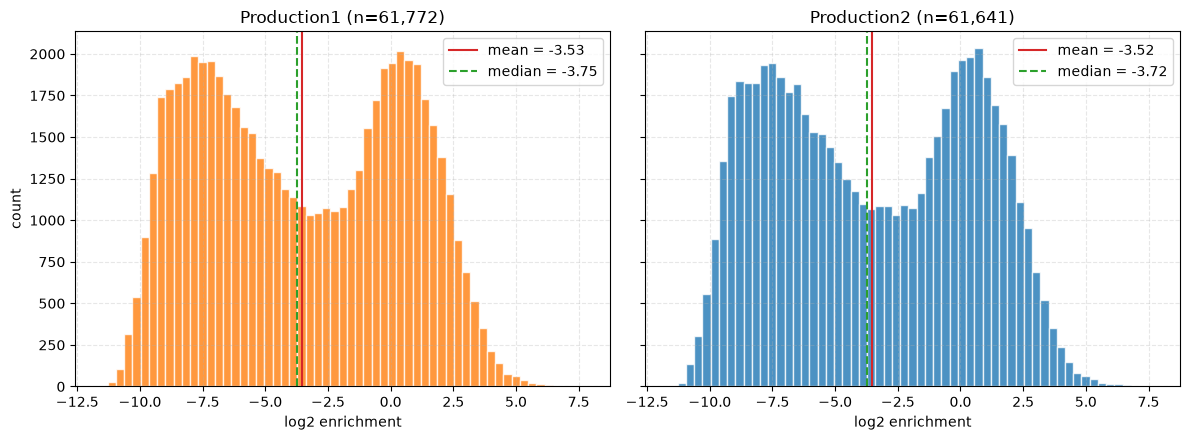

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True, sharey=True)

axes[0].hist(log2_prod1, bins=bins, color="tab:orange", alpha=0.8, edgecolor="white")
axes[0].axvline(log2_prod1.mean(), color="tab:red", linestyle="-", label=f"mean = {log2_prod1.mean():.2f}")
axes[0].axvline(np.median(log2_prod1), color="tab:green", linestyle="--", label=f"median = {np.median(log2_prod1):.2f}")
axes[0].set_title(f"Production1 (n={len(log2_prod1):,})")
axes[0].set_xlabel("log2 enrichment")
axes[0].set_ylabel("count")
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.3)

axes[1].hist(log2_prod2, bins=bins, color="tab:blue", alpha=0.8, edgecolor="white")
axes[1].axvline(log2_prod2.mean(), color="tab:red", linestyle="-", label=f"mean = {log2_prod2.mean():.2f}")
axes[1].axvline(np.median(log2_prod2), color="tab:green", linestyle="--", label=f"median = {np.median(log2_prod2):.2f}")
axes[1].set_title(f"Production2 (n={len(log2_prod2):,})")
axes[1].set_xlabel("log2 enrichment")
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.3)

fig.tight_layout()
plt.show()